# Chapter 15: Model Evaluation, Selection & Tuning Assessment


## Assignment Overview

**Business Context**: You're a data analyst working for a hotel chain. Management wants you to build a reliable model to predict whether guests will cancel their reservations. Rather than just fitting a single model, they need you to follow a **professional evaluation workflow**: evaluate models reliably using cross-validation, diagnose model behavior with learning and validation curves, tune hyperparameters systematically, and compare algorithms fairly before selecting a final model.

**Learning Objectives**:
- Understand why a single train/test split is insufficient for reliable model evaluation
- Use cross-validation (StratifiedKFold) to evaluate models with multiple metrics
- Diagnose bias and variance using learning curves
- Identify optimal hyperparameter ranges using validation curves
- Tune hyperparameters systematically using GridSearchCV and RandomizedSearchCV
- Compare multiple algorithms fairly using the same evaluation framework
- Evaluate a final model on a held-out test set
- Interpret performance differences using mean and standard deviation

**Important Notes**:
- This assignment focuses on **Chapter 15 content only** (model evaluation, selection, and tuning)
- You **WILL** split data into train/test sets and freeze the test set for final evaluation only
- All model development uses **cross-validation on the training set**
- Use `random_state=27` for all models and splits (for reproducibility)
- The test set is used **only once** at the very end

---

## Dataset Information

**Source**: Hotel Reservations Classification Dataset (Kaggle)
**Description**:
This dataset contains information about hotel reservations, including booking details, guest information, and reservation characteristics. The goal is to predict whether a reservation will be canceled.

**Target Variable**: `booking_status` - categorical variable indicating whether the reservation was "Canceled" or "Not_Canceled"

**Data Dictionary**:
| Variable | Description |
|---|---|
| Booking_ID | Unique identifier for each reservation |
| no_of_adults | Number of adults in the reservation |
| no_of_children | Number of children in the reservation |
| no_of_weekend_nights | Number of weekend nights (Saturday or Sunday) |
| no_of_week_nights | Number of week nights (Monday to Friday) |
| type_of_meal_plan | Type of meal plan selected (Meal Plan 1, Meal Plan 2, Meal Plan 3, Not Selected) |
| required_car_parking_space | Whether a car parking space is required (0 or 1) |
| room_type_reserved | Type of room reserved (Room_Type 1 through Room_Type 7) |
| lead_time | Number of days between booking date and arrival date |
| arrival_year | Year of arrival (2017 or 2018) |
| arrival_month | Month of arrival (1-12) |
| arrival_date | Day of the month of arrival (1-31) |
| market_segment_type | How the reservation was made (Online, Offline, Corporate, Complementary, Aviation) |
| repeated_guest | Whether the guest has previously stayed at the hotel (0 or 1) |
| no_of_previous_cancellations | Number of previous cancellations by the guest |
| no_of_previous_bookings_not_canceled | Number of previous bookings not canceled by the guest |
| avg_price_per_room | Average price per day of the reservation (in euros) |
| no_of_special_requests | Number of special requests made by the guest |
| booking_status | Target: "Canceled" or "Not_Canceled" |

**Note**: Expected checkpoint answers are based on using `random_state=27` throughout. Actual values may vary slightly if different random seeds are used.

---

# Part 1: Load and Prepare Data

In this section, you'll load the dataset and perform data preprocessing for model evaluation and selection.

## Question 1: Load and Explore the Dataset

Load the `Hotel Reservations.csv` file and perform initial exploration:
1. Load the dataset into a Pandas DataFrame
2. Display the dataset shape and first few rows
3. Check the distribution of the target variable `booking_status`
4. Calculate and display the cancellation rate percentage

**Checkpoint Question**: What percentage of reservations are canceled? Round to 2 decimal places (e.g., enter 32.76 not 0.3276 or 32.76%).


In [14]:
# Question 1: Load and explore the dataset

import pandas as pd
from pathlib import Path

# Handle either common filename convention for this dataset.
# Search both the notebook directory and current working directory so the
# notebook runs correctly whether launched from Chapter-15 or the repo root.
search_dirs = [Path.cwd(), Path.cwd() / "Chapter-15"]
candidate_names = ["hotel_reservations.csv", "Hotel Reservations.csv"]
candidate_files = [directory / name for directory in search_dirs for name in candidate_names]

for file_path in candidate_files:
    if file_path.exists():
        data_path = file_path
        break
else:
    raise FileNotFoundError(
        "Could not find hotel reservations dataset in the current directory or Chapter-15 folder."
    )

df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())

print("\nTarget distribution (booking_status):")
print(df["booking_status"].value_counts())

cancellation_rate = (df["booking_status"] == "Canceled").mean() * 100
print(f"\nCancellation rate: {cancellation_rate:.2f}%")

Dataset shape: (36275, 19)

First 5 rows:


,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled



Target distribution (booking_status):
booking_status
Not_Canceled    24390
Canceled        11885
Name: count, dtype: int64

Cancellation rate: 32.76%


## Question 2: Data Preprocessing and Train/Test Split

Prepare the data for modeling:
1. Create a binary target `is_canceled` from `booking_status`
2. Drop `Booking_ID` and `booking_status`
3. Identify numeric and categorical columns
4. Create a preprocessing pipeline using `ColumnTransformer`:
   - For numeric features: Use `SimpleImputer` with median strategy, then `StandardScaler`
   - For categorical features: Use `SimpleImputer` with most_frequent strategy, then `OneHotEncoder`
5. Create a `StratifiedKFold` cross-validation object (n_splits=5, shuffle=True, random_state=27)
6. Create train/test split (80/20, stratified by target, random_state=27)
7. Display the shapes of training and testing sets

**Checkpoint Question**: How many samples are in the training set?


In [15]:
# Question 2: Data preprocessing and train/test split

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 1) Binary target
is_canceled = (df["booking_status"] == "Canceled").astype(int)

# 2) Drop identifier and original target
X = df.drop(columns=["Booking_ID", "booking_status"])
y = is_canceled

# 3) Identify column types
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")

# 4) Preprocessing pipeline
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)

# 5) Cross-validation object
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=27)

# 6) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=27,
)

# 7) Display set shapes
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"Training samples: {X_train.shape[0]}")

Numeric columns (14): ['no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'required_car_parking_space', 'lead_time', 'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest', 'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests']
Categorical columns (3): ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']
X_train shape: (29020, 17)
X_test shape: (7255, 17)
y_train shape: (29020,)
y_test shape: (7255,)
Training samples: 29020


# Part 2: Cross-Validation Baselines

In this section, you'll establish baseline performance for two models using cross-validation with multiple metrics.

## Question 3: Logistic Regression Baseline with Multiple Metrics

Build a logistic regression baseline using cross-validation:
1. Create a logistic regression pipeline with preprocessing
2. Use `cross_validate` with multiple scoring metrics: accuracy, balanced_accuracy, f1, roc_auc, neg_log_loss
3. Use the same StratifiedKFold object (`skf`) created in Question 2
4. Display mean and standard deviation for each metric
5. Note: scikit-learn uses "negative" log loss so that higher values are always "better" -- multiply by -1 when reporting

**Checkpoint Question**: What is the mean cross-validated ROC AUC for logistic regression? Round to 4 decimal places.


In [16]:
# Question 3: Logistic regression baseline with multiple metrics

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate

log_reg_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=27)),
    ]
)

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "neg_log_loss": "neg_log_loss",
}

log_reg_cv_results = cross_validate(
    estimator=log_reg_pipeline,
    X=X_train,
    y=y_train,
    cv=skf,
    scoring=scoring,
    n_jobs=-1,
)

print("Logistic Regression CV Results (mean +/- std)")
print(f"Accuracy:          {log_reg_cv_results['test_accuracy'].mean():.4f} +/- {log_reg_cv_results['test_accuracy'].std():.4f}")
print(f"Balanced Accuracy: {log_reg_cv_results['test_balanced_accuracy'].mean():.4f} +/- {log_reg_cv_results['test_balanced_accuracy'].std():.4f}")
print(f"F1 Score:          {log_reg_cv_results['test_f1'].mean():.4f} +/- {log_reg_cv_results['test_f1'].std():.4f}")
print(f"ROC AUC:           {log_reg_cv_results['test_roc_auc'].mean():.4f} +/- {log_reg_cv_results['test_roc_auc'].std():.4f}")
print(f"Log Loss:          {-log_reg_cv_results['test_neg_log_loss'].mean():.4f} +/- {log_reg_cv_results['test_neg_log_loss'].std():.4f}")

Logistic Regression CV Results (mean +/- std)
Accuracy:          0.8043 +/- 0.0051
Balanced Accuracy: 0.7590 +/- 0.0069
F1 Score:          0.6776 +/- 0.0099
ROC AUC:           0.8636 +/- 0.0040
Log Loss:          0.4239 +/- 0.0053


## Question 4: Decision Tree Baseline with Cross-Validation

Build a decision tree baseline using cross-validation:
1. Create a decision tree pipeline with `max_depth=5` and `random_state=27`
2. Cross-validate with the same scoring dictionary and same CV object (`skf`)
3. Display mean and standard deviation for each metric

**Checkpoint Question**: What is the mean cross-validated accuracy for the decision tree? Round to 4 decimal places.


In [17]:
# Question 4: Decision tree baseline with cross-validation

from sklearn.tree import DecisionTreeClassifier

tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(max_depth=5, random_state=27)),
    ]
)

tree_cv_results = cross_validate(
    estimator=tree_pipeline,
    X=X_train,
    y=y_train,
    cv=skf,
    scoring=scoring,
    n_jobs=-1,
)

print("Decision Tree CV Results (mean +/- std)")
print(f"Accuracy:          {tree_cv_results['test_accuracy'].mean():.4f} +/- {tree_cv_results['test_accuracy'].std():.4f}")
print(f"Balanced Accuracy: {tree_cv_results['test_balanced_accuracy'].mean():.4f} +/- {tree_cv_results['test_balanced_accuracy'].std():.4f}")
print(f"F1 Score:          {tree_cv_results['test_f1'].mean():.4f} +/- {tree_cv_results['test_f1'].std():.4f}")
print(f"ROC AUC:           {tree_cv_results['test_roc_auc'].mean():.4f} +/- {tree_cv_results['test_roc_auc'].std():.4f}")
print(f"Log Loss:          {-tree_cv_results['test_neg_log_loss'].mean():.4f} +/- {tree_cv_results['test_neg_log_loss'].std():.4f}")

Decision Tree CV Results (mean +/- std)
Accuracy:          0.8328 +/- 0.0026
Balanced Accuracy: 0.7972 +/- 0.0106
F1 Score:          0.7307 +/- 0.0132
ROC AUC:           0.8804 +/- 0.0050
Log Loss:          0.3798 +/- 0.0062


# Part 3: Diagnostic Curves

In this section, you'll use learning curves to diagnose whether the logistic regression model suffers from high bias or high variance.

## Question 5: Learning Curve for Logistic Regression

Diagnose the logistic regression model using a learning curve:
1. Compute the learning curve using `learning_curve` with ROC AUC scoring
2. Use 10 training set sizes from 10% to 100% of the training data
3. Plot training and validation curves with `fill_between` for standard deviation bands
4. Print the final training and validation ROC AUC values and the gap between them
5. Interpret the pattern: does the model show high bias, high variance, or a good fit?

**Checkpoint Question**: Based on the learning curve, does the logistic regression model show primarily high bias, high variance, or a good fit? (Answer with "High Bias", "High Variance", or "Good Fit")


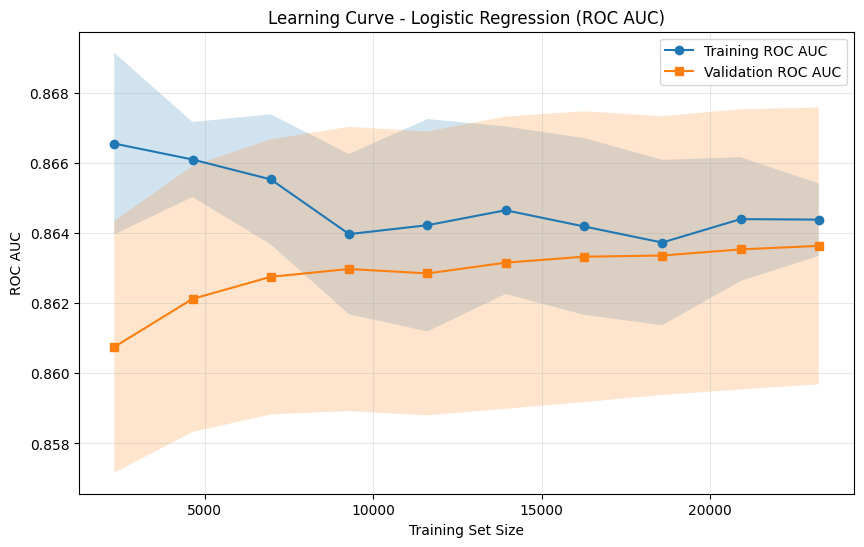

Final training ROC AUC: 0.8644
Final validation ROC AUC: 0.8636
Gap (train - validation): 0.0007
Learning-curve diagnosis: Good Fit


In [18]:
# Question 5: Learning curve for logistic regression

import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve

log_reg_lc_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("lr", LogisticRegression(max_iter=1000, random_state=27)),
    ]
)

train_sizes, train_scores, val_scores = learning_curve(
    estimator=log_reg_lc_pipeline,
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=skf,
    scoring="roc_auc",
    n_jobs=-1,
    shuffle=True,
    random_state=27,
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, marker="o", label="Training ROC AUC")
plt.plot(train_sizes, val_mean, marker="s", label="Validation ROC AUC")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)
plt.title("Learning Curve - Logistic Regression (ROC AUC)")
plt.xlabel("Training Set Size")
plt.ylabel("ROC AUC")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

final_train_auc = train_mean[-1]
final_val_auc = val_mean[-1]
auc_gap = final_train_auc - final_val_auc

print(f"Final training ROC AUC: {final_train_auc:.4f}")
print(f"Final validation ROC AUC: {final_val_auc:.4f}")
print(f"Gap (train - validation): {auc_gap:.4f}")

if auc_gap > 0.03:
    diagnosis = "High Variance"
elif final_val_auc < 0.80:
    diagnosis = "High Bias"
else:
    diagnosis = "Good Fit"

print(f"Learning-curve diagnosis: {diagnosis}")

# Part 4: Validation Curves

In this section, you'll use validation curves to identify the optimal hyperparameter value for a decision tree.

## Question 6: Validation Curve for Decision Tree (max_depth)

Explore the effect of tree depth on model performance:
1. Compute the validation curve varying `tree__max_depth` from 1 to 20
2. Plot training and validation ROC AUC curves
3. Identify the optimal `max_depth` from the validation curve (the depth with highest validation ROC AUC)

**Checkpoint Question**: At what max_depth does the validation ROC AUC peak? (Enter the integer value)


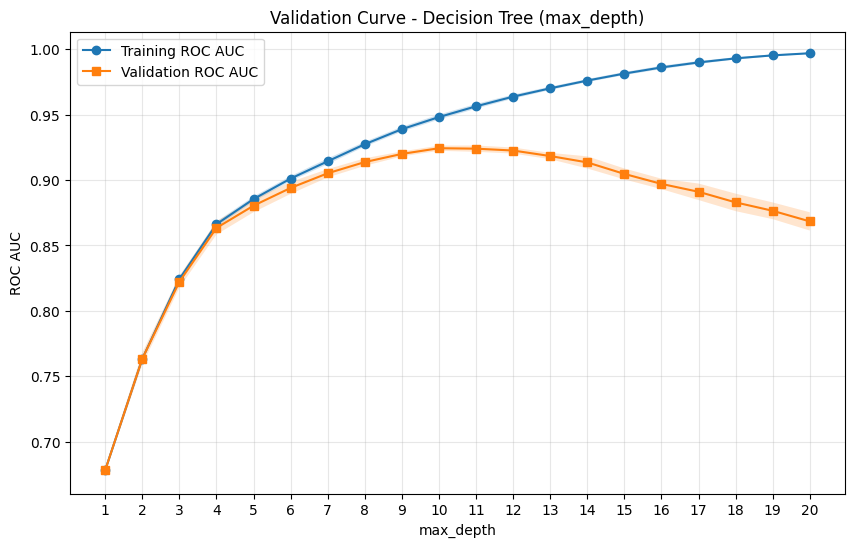

Best max_depth by validation ROC AUC: 10
Peak validation ROC AUC: 0.9243


In [19]:
# Question 6: Validation curve for decision tree (max_depth)

from sklearn.model_selection import validation_curve

tree_val_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("tree", DecisionTreeClassifier(random_state=27)),
    ]
)

depth_values = np.arange(1, 21)

train_scores_vc, val_scores_vc = validation_curve(
    estimator=tree_val_pipeline,
    X=X_train,
    y=y_train,
    param_name="tree__max_depth",
    param_range=depth_values,
    cv=skf,
    scoring="roc_auc",
    n_jobs=-1,
)

train_mean_vc = train_scores_vc.mean(axis=1)
train_std_vc = train_scores_vc.std(axis=1)
val_mean_vc = val_scores_vc.mean(axis=1)
val_std_vc = val_scores_vc.std(axis=1)

best_depth = int(depth_values[np.argmax(val_mean_vc)])

plt.figure(figsize=(10, 6))
plt.plot(depth_values, train_mean_vc, marker="o", label="Training ROC AUC")
plt.plot(depth_values, val_mean_vc, marker="s", label="Validation ROC AUC")
plt.fill_between(depth_values, train_mean_vc - train_std_vc, train_mean_vc + train_std_vc, alpha=0.2)
plt.fill_between(depth_values, val_mean_vc - val_std_vc, val_mean_vc + val_std_vc, alpha=0.2)
plt.title("Validation Curve - Decision Tree (max_depth)")
plt.xlabel("max_depth")
plt.ylabel("ROC AUC")
plt.xticks(depth_values)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Best max_depth by validation ROC AUC: {best_depth}")
print(f"Peak validation ROC AUC: {val_mean_vc.max():.4f}")

# Part 5: Hyperparameter Tuning

In this section, you'll use GridSearchCV and RandomizedSearchCV to systematically find optimal hyperparameters.

## Question 7: GridSearchCV for Logistic Regression

Tune logistic regression using GridSearchCV:
1. Define a parameter grid: `lr__C` = [0.01, 0.1, 1.0, 10.0], `lr__l1_ratio` = [0.0, 1.0] (the two endpoint cases: 0.0 = pure L2, 1.0 = pure L1), `lr__penalty` = ['elasticnet'], `lr__solver` = ['saga']
2. Use the same `skf` cross-validation object and `scoring='roc_auc'`
3. Display the best hyperparameters and best cross-validated ROC AUC score

**Note:** The `l1_ratio` parameter controls the mix of L1 and L2 regularization. This grid checks only the two endpoint cases (pure L2 and pure L1), not intermediate elastic-net mixtures. Setting `penalty='elasticnet'` and `solver='saga'` is required for `l1_ratio` to take effect in current versions of scikit-learn. Include them as fixed values in the grid.

**Checkpoint Question**: What is the best ROC AUC score from GridSearchCV? Round to 4 decimal places.

In [20]:
# Question 7: GridSearchCV for logistic regression

import warnings
from sklearn.model_selection import GridSearchCV

log_reg_grid_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("lr", LogisticRegression(max_iter=1000, random_state=27)),
    ]
)

param_grid_lr = {
    "lr__C": [0.01, 0.1, 1.0, 10.0],
    "lr__l1_ratio": [0.0, 1.0],
    "lr__penalty": ["elasticnet"],
    "lr__solver": ["saga"],
}

grid_search_lr = GridSearchCV(
    estimator=log_reg_grid_pipeline,
    param_grid=param_grid_lr,
    scoring="roc_auc",
    cv=skf,
    n_jobs=-1,
    refit=False,
)

# The assignment requires penalty in the grid; silence deprecation warnings from sklearn 1.8.
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=FutureWarning)
    grid_search_lr.fit(X_train, y_train)

print("Best Logistic Regression Parameters (GridSearchCV):")
print(grid_search_lr.best_params_)
print(f"Best CV ROC AUC: {grid_search_lr.best_score_:.4f}")

Best Logistic Regression Parameters (GridSearchCV):
{'lr__C': 10.0, 'lr__l1_ratio': 1.0, 'lr__penalty': 'elasticnet', 'lr__solver': 'saga'}
Best CV ROC AUC: 0.8636


## Question 8: RandomizedSearchCV for Gradient Boosting

Tune a gradient boosting model using RandomizedSearchCV:
1. Create a gradient boosting pipeline with preprocessing
2. Define parameter distributions: `gb__n_estimators` = [50, 100, 200], `gb__learning_rate` = [0.01, 0.05, 0.1, 0.2], `gb__max_depth` = [2, 3, 4, 5]
3. Use `n_iter=20`, same `skf`, `scoring='roc_auc'`, and `random_state=27`
4. Display the best hyperparameters and best cross-validated ROC AUC score

**Checkpoint Question**: What is the best ROC AUC score from RandomizedSearchCV? Round to 4 decimal places.


In [21]:
# Question 8: RandomizedSearchCV for gradient boosting

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV

gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("gb", GradientBoostingClassifier(random_state=27)),
    ]
)

param_distributions_gb = {
    "gb__n_estimators": [50, 100, 200],
    "gb__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "gb__max_depth": [2, 3, 4, 5],
}

random_search_gb = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=param_distributions_gb,
    n_iter=20,
    scoring="roc_auc",
    cv=skf,
    random_state=27,
    n_jobs=-1,
)

random_search_gb.fit(X_train, y_train)

print("Best Gradient Boosting Parameters (RandomizedSearchCV):")
print(random_search_gb.best_params_)
print(f"Best CV ROC AUC: {random_search_gb.best_score_:.4f}")

c:\Users\GeorgeColinRamsay\Documents\GitHub\IS-455\.venv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Gradient Boosting Parameters (RandomizedSearchCV):
{'gb__n_estimators': 200, 'gb__max_depth': 4, 'gb__learning_rate': 0.2}
Best CV ROC AUC: 0.9457


# Part 6: Fair Model Comparison

In this section, you'll cross-validate multiple models under identical conditions and build a comparison table.

## Question 9: Cross-Validate Multiple Models

Compare four models using the same evaluation framework:
1. Cross-validate the following models using the SAME `skf` and `scoring` dictionary:
   - Logistic Regression (max_iter=2000, random_state=27)
   - Decision Tree (max_depth=5, random_state=27)
   - Random Forest (n_estimators=100, random_state=27, n_jobs=-1)
   - Gradient Boosting (n_estimators=100, random_state=27)
2. Store results in a list of dictionaries for later use
3. Display the mean ROC AUC and standard deviation for each model

**Checkpoint Question**: Which model has the highest mean cross-validated ROC AUC? (Answer with exact model name)


In [22]:
# Question 9: Cross-validate multiple models

from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=27),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=27),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=27, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=27),
}

model_cv_results = []

for model_name, model_obj in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model_obj),
        ]
    )

    cv_out = cross_validate(
        estimator=pipeline,
        X=X_train,
        y=y_train,
        cv=skf,
        scoring=scoring,
        n_jobs=-1,
    )

    result = {
        "Model": model_name,
        "Accuracy Mean": cv_out["test_accuracy"].mean(),
        "Accuracy Std": cv_out["test_accuracy"].std(),
        "F1 Mean": cv_out["test_f1"].mean(),
        "F1 Std": cv_out["test_f1"].std(),
        "ROC AUC Mean": cv_out["test_roc_auc"].mean(),
        "ROC AUC Std": cv_out["test_roc_auc"].std(),
        "Log Loss Mean": -cv_out["test_neg_log_loss"].mean(),
        "Log Loss Std": cv_out["test_neg_log_loss"].std(),
    }
    model_cv_results.append(result)

for result in model_cv_results:
    print(f"{result['Model']}: ROC AUC = {result['ROC AUC Mean']:.4f} +/- {result['ROC AUC Std']:.4f}")

Logistic Regression: ROC AUC = 0.8636 +/- 0.0040
Decision Tree: ROC AUC = 0.8804 +/- 0.0050
Random Forest: ROC AUC = 0.9508 +/- 0.0016
Gradient Boosting: ROC AUC = 0.9139 +/- 0.0023


## Question 10: Build Comparison Table

Create a formatted comparison table:
1. Build a DataFrame with columns: Model, Accuracy (mean +/- std), F1, ROC AUC (mean +/- std), Log Loss
2. Sort by ROC AUC descending
3. Display the formatted table

**Checkpoint Question**: What is the mean cross-validated F1 score for the Random Forest model? Round to 4 decimal places.


In [23]:
# Question 10: Build comparison table

comparison_df = pd.DataFrame(model_cv_results)
comparison_df = comparison_df.sort_values(by="ROC AUC Mean", ascending=False).reset_index(drop=True)

comparison_table = pd.DataFrame(
    {
        "Model": comparison_df["Model"],
        "Accuracy (mean +/- std)": comparison_df.apply(
            lambda row: f"{row['Accuracy Mean']:.4f} +/- {row['Accuracy Std']:.4f}", axis=1
        ),
        "F1": comparison_df.apply(
            lambda row: f"{row['F1 Mean']:.4f} +/- {row['F1 Std']:.4f}", axis=1
        ),
        "ROC AUC (mean +/- std)": comparison_df.apply(
            lambda row: f"{row['ROC AUC Mean']:.4f} +/- {row['ROC AUC Std']:.4f}", axis=1
        ),
        "Log Loss": comparison_df.apply(
            lambda row: f"{row['Log Loss Mean']:.4f} +/- {row['Log Loss Std']:.4f}", axis=1
        ),
    }
)

display(comparison_table)

rf_f1 = comparison_df.loc[comparison_df["Model"] == "Random Forest", "F1 Mean"].iloc[0]
print(f"Random Forest mean CV F1: {rf_f1:.4f}")

,Model,Accuracy (mean +/- std),F1,ROC AUC (mean +/- std),Log Loss
0,Random Forest,0.8988 +/- 0.0047,0.8383 +/- 0.0081,0.9508 +/- 0.0016,0.2855 +/- 0.0185
1,Gradient Boosting,0.8508 +/- 0.0032,0.7533 +/- 0.0069,0.9139 +/- 0.0023,0.3460 +/- 0.0035
2,Decision Tree,0.8328 +/- 0.0026,0.7307 +/- 0.0132,0.8804 +/- 0.0050,0.3798 +/- 0.0062
3,Logistic Regression,0.8043 +/- 0.0051,0.6776 +/- 0.0099,0.8636 +/- 0.0040,0.4239 +/- 0.0053


Random Forest mean CV F1: 0.8383


# Part 7: Final Evaluation

In this section, you'll evaluate the best models on the held-out test set for the first and only time.

## Question 11: Evaluate Best Model on Held-Out Test Set

Evaluate the top models on the frozen test set:
1. Train the tuned Gradient Boosting model using the actual best parameters found in Question 8
2. Also train a default Random Forest (n_estimators=100) for comparison
3. Evaluate BOTH on the test set
4. Display test accuracy, ROC AUC, log loss, and F1 for each model

**Checkpoint Question**: What is the test ROC AUC for the tuned Gradient Boosting model? Round to 4 decimal places.


In [24]:
# Question 11: Evaluate best model on held-out test set

from sklearn.metrics import accuracy_score, f1_score, log_loss, roc_auc_score

# Reuse the actual best parameters discovered in Q8 rather than hardcoding them.
tuned_gb_params = {
    key.replace("gb__", ""): value for key, value in random_search_gb.best_params_.items()
}

tuned_gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "gb",
            GradientBoostingClassifier(**tuned_gb_params, random_state=27),
        ),
    ]
)

rf_test_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("rf", RandomForestClassifier(n_estimators=100, random_state=27, n_jobs=-1)),
    ]
)

tuned_gb_pipeline.fit(X_train, y_train)
rf_test_pipeline.fit(X_train, y_train)

models_for_test = {
    "Tuned Gradient Boosting": tuned_gb_pipeline,
    "Random Forest": rf_test_pipeline,
}

test_metrics = []
for name, fitted_model in models_for_test.items():
    y_pred = fitted_model.predict(X_test)
    y_proba = fitted_model.predict_proba(X_test)[:, 1]

    metrics_row = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_proba),
        "Log Loss": log_loss(y_test, y_proba),
        "F1": f1_score(y_test, y_pred),
    }
    test_metrics.append(metrics_row)

test_results_df = pd.DataFrame(test_metrics)
display(test_results_df)

for _, row in test_results_df.iterrows():
    print(
        f"{row['Model']}: Accuracy={row['Accuracy']:.4f}, "
        f"ROC AUC={row['ROC AUC']:.4f}, Log Loss={row['Log Loss']:.4f}, F1={row['F1']:.4f}"
    )

best_test_model = test_results_df.sort_values(by="ROC AUC", ascending=False).iloc[0]
print(
    f"Best held-out ROC AUC: {best_test_model['Model']} ({best_test_model['ROC AUC']:.4f})"
)

,Model,Accuracy,ROC AUC,Log Loss,F1
0,Tuned Gradient Boosting,0.887112,0.949122,0.264622,0.819643
1,Random Forest,0.906961,0.957130,0.266782,0.852265


Tuned Gradient Boosting: Accuracy=0.8871, ROC AUC=0.9491, Log Loss=0.2646, F1=0.8196
Random Forest: Accuracy=0.9070, ROC AUC=0.9571, Log Loss=0.2668, F1=0.8523
Best held-out ROC AUC: Random Forest (0.9571)


## Question 12: Confusion Matrix and Classification Metrics

Analyze the tuned Gradient Boosting model's predictions in detail:
1. Generate a confusion matrix for the tuned GB model on the test set
2. Plot the confusion matrix as a heatmap
3. Calculate and display precision and recall for the canceled class (is_canceled=1)

**Checkpoint Question**: What is the recall for the canceled class (is_canceled=1) for the tuned Gradient Boosting model? Round to 4 decimal places.


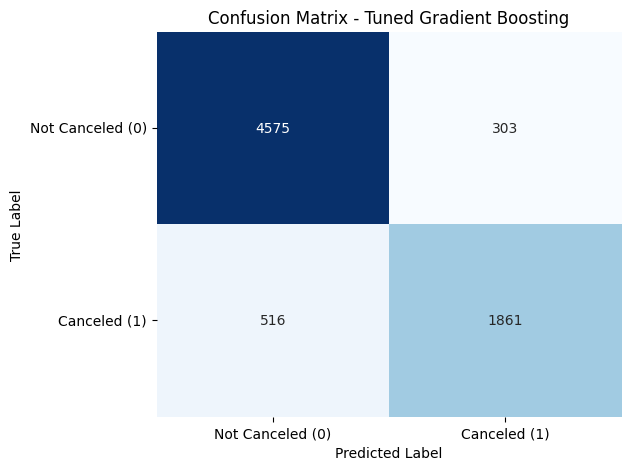

Precision (Canceled=1): 0.8600
Recall (Canceled=1): 0.7829


In [25]:
# Question 12: Confusion matrix and classification metrics

import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_score, recall_score

y_test_pred_gb = tuned_gb_pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_test_pred_gb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix - Tuned Gradient Boosting")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0.5, 1.5], ["Not Canceled (0)", "Canceled (1)"])
plt.yticks([0.5, 1.5], ["Not Canceled (0)", "Canceled (1)"], rotation=0)
plt.show()

precision_canceled = precision_score(y_test, y_test_pred_gb, pos_label=1)
recall_canceled = recall_score(y_test, y_test_pred_gb, pos_label=1)

print(f"Precision (Canceled=1): {precision_canceled:.4f}")
print(f"Recall (Canceled=1): {recall_canceled:.4f}")

# Part 8: Conceptual Understanding (Multiple Choice Questions)

Answer the following multiple choice questions to demonstrate your understanding of model evaluation, selection, and tuning from Chapter 15. Each question references your analysis results and tests Chapter 15 concepts.

Select the **best answer** for each question (A, B, C, D, or E).

---

## Question 13: Cross-Validation Purpose

Your learning curve for logistic regression (Question 5) showed both training and validation curves converging quickly with a very small gap. Your manager asks: "Why didn't you just use a single train/test split to evaluate the model?" Which response is most accurate?

**A)** A single split is faster and produces the same ranking of models regardless of how the data is divided, so cross-validation is unnecessary computational overhead for most practical problems.

**B)** Cross-validation produces multiple performance estimates, revealing both typical performance and variability, which a single split cannot provide.

**C)** Cross-validation is only necessary for small datasets with fewer than 1,000 observations; larger datasets like this one do not benefit from it.

**D)** Cross-validation is primarily used to increase the training set size, which improves model accuracy compared to a single train/test split.

**E)** Cross-validation replaces the need for a final test set, so you can use all data for training and validation without holding anything out.


## Question 14: Learning Curve Interpretation

Your learning curve (Question 5) showed logistic regression with both curves converging at approximately 0.86 ROC AUC with a gap of only 0.001. If you still need meaningfully better performance, which action would most likely help?

**A)** Collect more training data, because the validation curve has not yet plateaued and more data will continue improving generalization.

**B)** Increase regularization strength (lower C), because the small gap indicates overfitting that needs to be controlled.

**C)** Try a more flexible model family like tree-based methods, because the tiny gap suggests little overfitting and performance may now be limited by the linear model's flexibility.

**D)** Reduce the number of features, because too many features are causing the model to underfit by spreading attention across irrelevant variables.

**E)** Increase max_iter for logistic regression, because the model has not converged during training and needs more optimization iterations.


## Question 15: Validation Curve Interpretation

Your validation curve for the decision tree (Question 6) showed training ROC AUC increasing steadily toward 1.0 while validation ROC AUC peaked around depth 10 and then plateaued. A colleague suggests using max_depth=20 because "the training score is higher." Why is this reasoning flawed?

**A)** Deeper trees take longer to train, so the computational cost outweighs any performance benefit at depth 20 compared to depth 10.

**B)** The validation curve shows that beyond depth 10, the model is overfitting -- higher training scores reflect memorization of training data, not better generalization.

**C)** Decision trees cannot effectively use depths greater than 15 because the tree structure becomes too fragmented to make reliable predictions.

**D)** The training score at depth 20 is artificially inflated because cross-validation leaks information from the validation folds into the training folds during the preprocessing and fitting steps, producing an optimistically biased estimate.

**E)** Deeper trees require more features than are available in this dataset, so depths beyond 10 produce degenerate splits.


## Question 16: GridSearchCV vs RandomizedSearchCV

In Questions 7 and 8, you used GridSearchCV for logistic regression and RandomizedSearchCV for gradient boosting. Your GridSearchCV tested 8 combinations while RandomizedSearchCV tested 20 out of 48 possible combinations. When should you prefer RandomizedSearchCV over GridSearchCV?

**A)** RandomizedSearchCV always finds better hyperparameters because random sampling explores the space more thoroughly than exhaustive search.

**B)** RandomizedSearchCV is preferred when the search space is large, because it provides a fixed computational budget regardless of the number of hyperparameters.

**C)** RandomizedSearchCV should only be used for ensemble methods that have many hyperparameters, while GridSearchCV is more appropriate for simpler linear models like logistic regression that have fewer parameters to tune.

**D)** RandomizedSearchCV is faster because it uses fewer cross-validation folds than GridSearchCV, reducing the total number of model fits.

**E)** RandomizedSearchCV is preferred when you need exact reproducibility, because grid search results vary depending on the order of evaluation.


## Question 17: Fair Model Comparison

In your comparison table (Question 10), Random Forest had the highest cross-validated ROC AUC (0.9508) while Gradient Boosting had 0.9139 with default hyperparameters. However, after tuning (Question 8), Gradient Boosting achieved 0.9457. What is the most important lesson about fair model comparison?

**A)** Always choose the model with the highest ROC AUC, since ROC AUC is the most reliable metric for all classification problems regardless of business context.

**B)** Default hyperparameter comparisons provide a definitive ranking -- if a model performs poorly with defaults, tuning is unlikely to change the outcome significantly.

**C)** Fair comparison requires same evaluation conditions, and ideally each model should be tuned before final comparison, since default settings favor some algorithms more than others.

**D)** The model with the lowest standard deviation across folds is always the best choice because stability is more important than absolute performance.

**E)** Cross-validation comparison should always be followed by a statistical significance test; without it, any observed performance difference is unreliable.


## Closed-Resource Conceptual Questions (Q18–Q22)

The following five questions assess your conceptual understanding of the model evaluation, selection, and tuning principles covered in Chapter 15. These questions are designed for **closed-resource, in-class assessment** — answer them based on what you have learned from the chapter, without using AI tools, the textbook, or other resources.

Select the **best answer** for each question (A, B, C, D, or E).

---

## Question 18: K-Fold Cross-Validation Mechanics

In 5-fold cross-validation on a dataset of 1,000 observations, the data is divided into 5 equal parts. How many total model training runs occur, and how many observations are used for training in each run?

**A)** 5 training runs, each using 800 observations for training and 200 for validation.

**B)** 5 training runs, each using 200 observations for training and 800 for validation.

**C)** 10 training runs, each using 500 observations for training and 500 for validation.

**D)** 1 training run using all 1,000 observations, validated by splitting predictions into 5 groups.

**E)** 5 training runs, each using all 1,000 observations for both training and validation simultaneously.


## Question 19: Diagnosing Model Problems from Learning Curves

A model's learning curve shows that training accuracy is 0.98 while validation accuracy is 0.71 even when using the full training set. The gap between the two curves is not closing as more data is added. What does this indicate, and what is the most appropriate remedy?

**A)** High bias; the model is too simple and needs more features or a more flexible algorithm.

**B)** High variance; the model is memorizing training data, so reducing complexity or adding regularization would help.

**C)** Good fit; a training-validation gap is normal and expected for all well-performing models.

**D)** Insufficient data; collecting more training observations will eventually close the gap between the curves.

**E)** A preprocessing error; the large gap between training and validation indicates that the two sets have systematically different feature distributions.


## Question 20: Test Set Protocol

A data scientist evaluates 15 different model configurations on a held-out test set, selects the one with the best test performance, and reports that test score as the expected performance on new data. What is the fundamental problem with this approach?

**A)** Nothing is wrong; the test set provides an unbiased estimate for whichever model performs best on it.

**B)** Using 15 configurations is too few to find the best model; at least 50 should be tested on the held-out set.

**C)** Repeatedly evaluating on the test set causes the selection process to overfit to the test data, making the reported score optimistically biased.

**D)** The test set should always be larger than the training set to ensure statistically reliable evaluation when comparing multiple model configurations simultaneously.

**E)** The problem is computational inefficiency; evaluating on the test set is slower than using cross-validation on the training set.


## Question 21: Choosing the Right Evaluation Metric

A hospital builds a model to screen patients for a rare but life-threatening condition that affects 2% of patients. The model predicts "no risk" for every patient and achieves 98% accuracy. Which metric would best reveal this model's failure?

**A)** Accuracy, because it already shows the model is performing well at 98%.

**B)** Precision, because it measures what fraction of predicted positive cases are truly positive.

**C)** Recall (sensitivity), because it measures what fraction of actual positive cases the model identifies -- which is 0% here.

**D)** ROC AUC, because it evaluates the model's ranking quality across all possible classification thresholds.

**E)** Log loss, because it penalizes the model for assigning low probabilities to the true class.


## Question 22: Data Leakage in Preprocessing

A student fits a StandardScaler on the entire dataset before splitting into training and test sets. The model achieves ROC AUC of 0.95 on the test set but only 0.88 when deployed on truly new data. What caused this discrepancy?

**A)** The model needed more training iterations to converge properly before deployment.

**B)** StandardScaler is inappropriate for this type of dataset; a different scaler like MinMaxScaler or RobustScaler would produce consistent results and eliminate the discrepancy.

**C)** Fitting the scaler on all data before splitting leaked test set statistics into the preprocessing step, producing an inflated test score.

**D)** The deployment data must come from a different time period, which always causes performance drops unrelated to methodology.

**E)** The test set was too small, causing a random upward fluctuation that happened to reach 0.95 by chance.


# Summary and Reflection